In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.optimize import minimize

plt.style.use("default")

In [3]:
assets = ["AAPL", "MSFT", "VOD.L", "HSBA.L", "BP.L", "ICLN", "ESGU"]

start_date = "2018-01-01"
end_date = "2025-12-05"

print("Downloading:", assets)

raw = yf.download(
    assets,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

valid_cols = raw.columns[raw.isna().mean() < 0.25]
data = raw[valid_cols].ffill().bfill()

print("Assets used:", list(data.columns))
data.tail()

Downloading: ['AAPL', 'MSFT', 'VOD.L', 'HSBA.L', 'BP.L', 'ICLN', 'ESGU']
Assets used: ['AAPL', 'BP.L', 'ESGU', 'HSBA.L', 'ICLN', 'MSFT', 'VOD.L']


Ticker,AAPL,BP.L,ESGU,HSBA.L,ICLN,MSFT,VOD.L
Date,,,,,,,
2025-11-28,278.850006,454.200012,149.440002,1070.199951,16.990000,492.010010,94.019997
2025-12-01,283.100006,457.549988,148.740005,1079.599976,16.549999,486.739990,92.360001
2025-12-02,286.190002,457.950012,149.059998,1087.800049,16.719999,490.000000,93.940002
2025-12-03,284.149994,464.000000,149.610001,1070.199951,16.639999,477.730011,95.040001
2025-12-04,280.700012,465.000000,149.779999,1074.400024,16.969999,480.839996,95.300003


In [4]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,BP.L,ESGU,HSBA.L,ICLN,MSFT,VOD.L
Date,,,,,,,
2018-01-03,-0.000174,0.012947,0.008553,-0.002222,-0.002114,0.004654,-0.001497
2018-01-04,0.004645,0.011065,0.005258,0.003537,-0.007415,0.008802,0.007924
2018-01-05,0.011385,-0.000755,0.004555,-0.003394,0.003202,0.012398,0.006375
2018-01-08,-0.003715,-0.004154,0.003074,-0.007204,0.014893,0.001021,0.003590
2018-01-09,-0.000114,0.001137,0.004805,0.010949,-0.002096,-0.000680,0.001473


In [5]:
mean_returns = returns.mean()
volatility = returns.std()
correlation = returns.corr()

risk_table = pd.DataFrame({
    "Mean Return": mean_returns,
    "Volatility": volatility
})

risk_table

,Mean Return,Volatility
Ticker,,
AAPL,0.001136,0.019245
BP.L,0.000155,0.020245
ESGU,0.000592,0.012411
HSBA.L,0.000299,0.016123
ICLN,0.000500,0.017866
MSFT,0.001042,0.017703
VOD.L,-0.000293,0.016977


In [6]:
np.random.seed(42)

esg_scores = pd.DataFrame({
    "Asset": data.columns,
    "ESG_Score": np.random.randint(50, 95, size=len(data.columns))
}).set_index("Asset")

esg_scores

,ESG_Score
Asset,
AAPL,88
BP.L,78
ESGU,64
HSBA.L,92
ICLN,57
MSFT,70
VOD.L,88


In [7]:
esg_threshold = 70  # keep only assets with ESG ≥ 70

filtered_assets = esg_scores[esg_scores["ESG_Score"] >= esg_threshold].index
filtered_returns = returns[filtered_assets]

print("Assets passing ESG filter:", list(filtered_assets))
filtered_returns.tail()

Assets passing ESG filter: ['AAPL', 'BP.L', 'HSBA.L', 'MSFT', 'VOD.L']


Ticker,AAPL,BP.L,HSBA.L,MSFT,VOD.L
Date,,,,,
2025-11-28,0.004684,0.016107,0.004883,0.013409,-0.002546
2025-12-01,0.015241,0.007376,0.008783,-0.010711,-0.017656
2025-12-02,0.010915,0.000874,0.007595,0.006698,0.017107
2025-12-03,-0.007128,0.013211,-0.016180,-0.025041,0.011710
2025-12-04,-0.012141,0.002155,0.003925,0.006510,0.002736


In [8]:
mu = filtered_returns.mean()
cov = filtered_returns.cov()
num_assets = len(mu)

def portfolio_stats(weights):
    ret = np.dot(weights, mu)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return ret, vol

def negative_sharpe(weights):
    ret, vol = portfolio_stats(weights)
    return -(ret / vol)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_weights = np.ones(num_assets) / num_assets

result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

opt_weights = result.x
opt_weights

array([4.29349534e-01, 1.64636633e-17, 1.26995364e-01, 4.43655102e-01,
       7.80356195e-19])

In [9]:
frontier_returns = []
frontier_vols = []

for r_target in np.linspace(mu.min(), mu.max(), 40):

    constraints_frontier = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - r_target}
    )

    res = minimize(
        lambda w: np.sqrt(np.dot(w.T, np.dot(cov, w))),
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_frontier
    )

    if res.success:
        ret, vol = portfolio_stats(res.x)
        frontier_returns.append(ret)
        frontier_vols.append(vol)

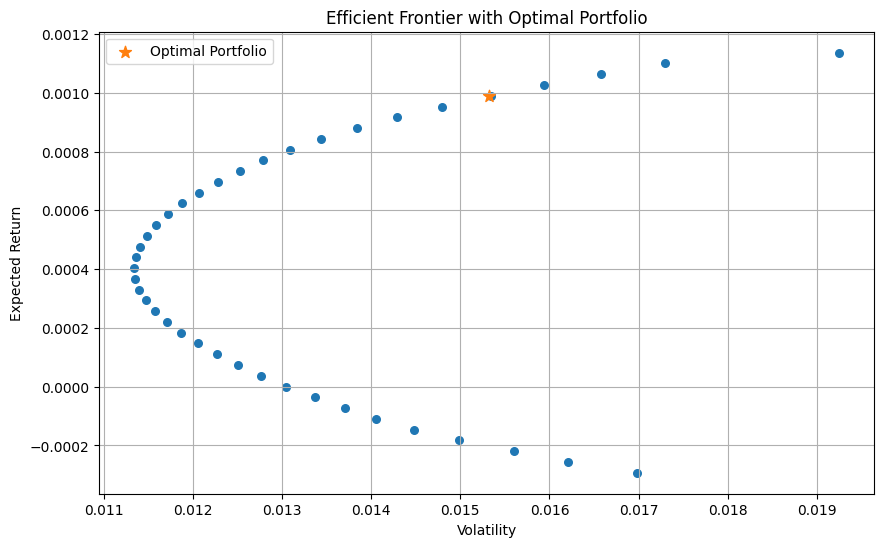

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(frontier_vols, frontier_returns, s=30)
opt_ret, opt_vol = portfolio_stats(opt_weights)
plt.scatter(opt_vol, opt_ret, s=80, marker="*", label="Optimal Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Optimal Portfolio")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
final_portfolio = pd.DataFrame({
    "Asset": filtered_assets,
    "Weight": opt_weights,
    "ESG Score": esg_scores.loc[filtered_assets]["ESG_Score"].values
}).sort_values("Weight", ascending=False)

final_portfolio

,Asset,Weight,ESG Score
3,MSFT,4.436551e-01,70
0,AAPL,4.293495e-01,88
2,HSBA.L,1.269954e-01,92
1,BP.L,1.646366e-17,78
4,VOD.L,7.803562e-19,88


In [12]:
final_portfolio.to_csv("Portfolio_Optimizer_Results.csv", index=False)
"File saved: Portfolio_Optimizer_Results.csv"

'File saved: Portfolio_Optimizer_Results.csv'

In [13]:
opt_return, opt_vol = portfolio_stats(opt_weights)

summary = pd.DataFrame({
    "Metric": ["Expected Return", "Expected Volatility", "Sharpe Ratio", "ESG Filter Used"],
    "Value": [
        round(opt_return, 4),
        round(opt_vol, 4),
        round(opt_return/opt_vol, 4),
        f"≥ {esg_threshold}"
    ]
})

summary

,Metric,Value
0,Expected Return,0.001
1,Expected Volatility,0.0153
2,Sharpe Ratio,0.0645
3,ESG Filter Used,≥ 70


In [14]:
# --- Annualise and report metrics (add to notebook) ---
import math
TRADING_DAYS = 252

# daily metrics from your optimizer
daily_return = float(opt_return)   # from portfolio_stats(opt_weights) earlier
daily_vol = float(opt_vol)

# annualise
annual_return = daily_return * TRADING_DAYS
annual_vol = daily_vol * math.sqrt(TRADING_DAYS)
annual_sharpe = annual_return / annual_vol if annual_vol != 0 else float('nan')

annual_summary = {
    "daily_return": round(daily_return, 6),
    "daily_volatility": round(daily_vol, 6),
    "annual_return": round(annual_return, 4),
    "annual_volatility": round(annual_vol, 4),
    "annual_sharpe": round(annual_sharpe, 3),
    "esg_filter": f"≥ {esg_threshold}"
}

import json
print("=== Annualised Metrics ===")
print(json.dumps(annual_summary, indent=2))

# Save to artifacts
import os
os.makedirs("artifacts_project2", exist_ok=True)
with open("artifacts_project2/annualised_metrics.json", "w") as f:
    json.dump(annual_summary, f, indent=2)

=== Annualised Metrics ===
{
  "daily_return": 0.000988,
  "daily_volatility": 0.015319,
  "annual_return": 0.249,
  "annual_volatility": 0.2432,
  "annual_sharpe": 1.024,
  "esg_filter": "\u2265 70"
}
